## Setup & load

In [112]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

In [113]:
roads   = pd.read_csv('../data/raw/roads.csv')
traffic = pd.read_csv('../data/raw/traffic.csv')
weather = pd.read_csv('../data/raw/weather.csv')
trips   = pd.read_csv('../data/raw/trips.csv')

for name, df in [('roads', roads), ('traffic', traffic),
                 ('weather', weather), ('trips', trips)]:
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")

roads: 25,000 rows × 5 cols
traffic: 100,000 rows × 6 cols
weather: 75,000 rows × 5 cols
trips: 250,000 rows × 11 cols


## Clean roads.csv

In [114]:
roads = roads.dropna(subset=['road_id']).copy()
print(f"After dropping null road_id: {len(roads):,} rows")

After dropping null road_id: 24,000 rows


In [115]:
roads = roads.drop_duplicates(subset=['road_id'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(roads):,} rows")

After dedup: 22,000 rows


In [116]:
road_type_map = {
    'highway': 'highway', 'hghway': 'highway', 'highwy': 'highway',
    'urban':   'urban',   'urbn':   'urban',   'urbna':  'urban',
    'residential': 'residential', 'resdntl': 'residential',
    'residental':  'residential',
}
roads['road_type'] = (roads['road_type']
    .str.strip().str.lower()
    .map(road_type_map))

print(roads['road_type'].value_counts(dropna=False))

road_type
residential    8916
urban          7616
highway        5468
Name: count, dtype: int64


In [117]:
zone_map = {
    'commercial': 'commercial', 'comerical':  'commercial',
    'commercail': 'commercial', 'commercal':  'commercial',
    'industrial': 'industrial', 'industral':  'industrial',
    'residential': 'residential', 'residental': 'residential',
    'residntl':   'residential',
}
roads['zone_type'] = (roads['zone_type']
    .str.strip().str.lower()
    .map(zone_map))   # unmapped → NaN (already null)

print(roads['zone_type'].value_counts(dropna=False))

zone_type
commercial     8060
residential    7968
industrial     4187
NaN            1785
Name: count, dtype: int64


In [118]:
# Valid lane range: 1–8; replace out-of-range with NaN
roads['num_lanes'] = roads['num_lanes'].where(
    roads['num_lanes'].between(1, 8))

# Valid signal range: 0–20
roads['num_signals'] = roads['num_signals'].where(
    roads['num_signals'].between(0, 20))

# Cast to nullable int
roads['num_lanes']   = roads['num_lanes'].astype('Int64')
roads['num_signals'] = roads['num_signals'].astype('Int64')

print(roads[['num_lanes','num_signals']].describe())

       num_lanes  num_signals
count    19946.0      20653.0
mean    2.963501     6.829468
std     1.325898     4.204725
min          1.0          0.0
25%          2.0          3.0
50%          3.0          7.0
75%          4.0         10.0
max          6.0         15.0


In [119]:
print(roads.isnull().sum())
print(roads.dtypes)
roads.head(3)

road_id           0
road_type         0
num_lanes      2054
num_signals    1347
zone_type      1785
dtype: int64
road_id        object
road_type      object
num_lanes       Int64
num_signals     Int64
zone_type      object
dtype: object


,road_id,road_type,num_lanes,num_signals,zone_type
0,RD08466,urban,<NA>,9,commercial
1,RD01426,residential,2,7,residential
2,RD00830,residential,<NA>,5,residential


## Clean weather.csv

In [120]:
def parse_weather_ts(s):
    """Try 5 known formats in order of specificity."""
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    formats = [
        '%Y-%m-%d %H:%M:%S',   # 2023-12-11 18:37:32
        '%Y-%m-%d',            # 2023-11-01
        '%d/%m/%y %H:%M',      # 22/09/23 03:27
        '%d/%m/%y',            # 14/06/23
        '%m-%d-%Y %H:%M',      # 11-30-2023 15:12
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

weather['timestamp'] = weather['timestamp'].apply(parse_weather_ts)
print("Unparseable:", weather['timestamp'].isna().sum())

Unparseable: 0


In [121]:
weather_map = {
    'clear': 'clear', 'clr': 'clear', 'sunny': 'clear',
    'rain':  'rain',  'raining': 'rain', 'rainy': 'rain',
    'fog':   'fog',   'foggy': 'fog',
}
weather['weather_type'] = (weather['weather_type']
    .str.strip().str.lower()
    .map(weather_map))   # blanks and unknowns → NaN

print(weather['weather_type'].value_counts(dropna=False))

weather_type
clear    46437
rain     14960
fog      12494
NaN       1109
Name: count, dtype: int64


In [122]:
weather['temperature_c'] = weather['temperature_c'].where(
    weather['temperature_c'].between(-3, 55))

print(weather['temperature_c'].describe())

count    73271.000000
mean        20.142758
std         11.290981
min         -3.000000
25%         10.100000
50%         20.200000
75%         30.100000
max         55.000000
Name: temperature_c, dtype: float64


In [123]:
vis_bounds = {'fog': (0.05, 4.0), 'rain': (1.0, 8.0), 'clear': (4.0, 12.0)}

def clip_visibility(row):
    wt = row['weather_type']
    v  = row['visibility_km']
    if pd.isna(wt) or pd.isna(v):
        return v
    lo, hi = vis_bounds.get(wt, (0.05, 12.0))
    return v if lo <= v <= hi else np.nan

weather['visibility_km'] = weather.apply(clip_visibility, axis=1)
print(weather['visibility_km'].describe())

count    71369.000000
mean         5.884202
std          2.648545
min          0.020000
25%          3.800000
50%          6.300000
75%          8.000000
max         20.800000
Name: visibility_km, dtype: float64


In [124]:
weather_agg = (weather
    .groupby('weather_id')
    .agg(
        weather_type  = ('weather_type',  lambda x: x.mode()[0] if x.notna().any() else np.nan),
        temperature_c = ('temperature_c', 'mean'),
        visibility_km = ('visibility_km', 'mean'),
        timestamp     = ('timestamp',     'min'),   # earliest reading for that event
    )
    .reset_index()
)

print(f"weather collapsed: {len(weather):,} → {len(weather_agg):,} rows")

weather collapsed: 75,000 → 37,941 rows


In [125]:
print(weather.isnull().sum())
weather.head(3)

weather_id          0
timestamp           0
weather_type     1109
temperature_c    1729
visibility_km    3631
dtype: int64


,weather_id,timestamp,weather_type,temperature_c,visibility_km
0,33272,2023-06-14 00:00:00,rain,29.9,6.0
1,59810,2023-09-22 03:27:00,rain,19.1,2.2
2,6974,2023-12-11 18:37:32,clear,7.6,6.0


## Clean traffic.csv

In [126]:
traffic = traffic.drop_duplicates(subset=['traffic_id'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(traffic):,} rows")

After dedup: 96,000 rows


In [127]:
traffic['hour'] = traffic['hour'].where(
    traffic['hour'].between(0, 23))
traffic['hour'] = traffic['hour'].astype('Int64')
print("Invalid hours remaining:", traffic['hour'].isna().sum())

Invalid hours remaining: 2850


In [128]:
day_map = {
    '0':'0','1':'1','2':'2','3':'3','4':'4','5':'5','6':'6',
    'monday':'0','mon':'0','tuesday':'1','tue':'1',
    'wednesday':'2','wed':'2','thursday':'3','thu':'3',
    'friday':'4','fri':'4','saturday':'5','sat':'5',
    'sunday':'6','sun':'6',
}
traffic['day_of_week'] = (traffic['day_of_week']
    .astype(str).str.strip().str.lower()
    .map(day_map)
    .astype('Int64'))

print(traffic['day_of_week'].value_counts(dropna=False))

day_of_week
4       15720
5       15589
0       15568
3       11871
1       11800
6       11781
2       11741
<NA>     1930
Name: count, dtype: Int64


In [129]:
tl_map = {
    'high':'high','hgh':'high','hi':'high',
    'medium':'medium','med':'medium','medum':'medium',
    'low':'low','lo':'low',
}
traffic['traffic_level'] = (traffic['traffic_level']
    .str.strip().str.lower()
    .map(tl_map))

print(traffic['traffic_level'].value_counts(dropna=False))

traffic_level
low       35005
medium    30944
high      26224
NaN        3827
Name: count, dtype: int64


In [130]:
traffic['avg_speed_kmph'] = traffic['avg_speed_kmph'].where(
    traffic['avg_speed_kmph'].between(1, 120))

print(traffic['avg_speed_kmph'].describe())

count    93147.000000
mean        43.623218
std         19.357293
min         10.000000
25%         26.800000
50%         45.500000
75%         58.300000
max         80.000000
Name: avg_speed_kmph, dtype: float64


In [131]:
traffic['zone_type'] = (traffic['zone_type']
    .str.strip().str.lower()
    .map(zone_map))   # zone_map defined in Step 1d; extras → NaN

print(traffic['zone_type'].value_counts(dropna=False))

zone_type
commercial     25747
industrial     25535
NaN            23187
residential    21531
Name: count, dtype: int64


In [132]:
trips['timestamp'] = trips['timestamp'].apply(parse_weather_ts)
print("Unparseable timestamps:", trips['timestamp'].isna().sum())

Unparseable timestamps: 3942


In [133]:
LAT_MIN, LAT_MAX =  6.0, 37.0   # India bounding box
LON_MIN, LON_MAX = 68.0, 98.0

for col, lo, hi in [
    ('start_lat', LAT_MIN, LAT_MAX), ('start_lon', LON_MIN, LON_MAX),
    ('end_lat',   LAT_MIN, LAT_MAX), ('end_lon',   LON_MIN, LON_MAX),
]:
    before = trips[col].isna().sum()
    trips[col] = trips[col].where(trips[col].between(lo, hi))
    after  = trips[col].isna().sum()
    print(f"{col}: nulled {after - before:,} out-of-range values")

start_lat: nulled 2,756 out-of-range values
start_lon: nulled 2,763 out-of-range values
end_lat: nulled 2,833 out-of-range values
end_lon: nulled 2,783 out-of-range values


In [134]:
trips['distance_km'] = trips['distance_km'].where(
    trips['distance_km'].between(0.01, 100))

print(trips['distance_km'].describe())

count    236411.000000
mean          5.806369
std           5.216437
min           0.500000
25%           1.740000
50%           4.140000
75%           8.330000
max          20.000000
Name: distance_km, dtype: float64


In [135]:
trips['travel_time_min'] = trips['travel_time_min'].where(
    trips['travel_time_min'].between(0.1, 600))  # 10 hrs max

print(trips['travel_time_min'].describe())

count    239919.000000
mean         21.797924
std          40.635117
min           0.260000
25%           6.440000
50%          12.290000
75%          24.170000
max         599.370000
Name: travel_time_min, dtype: float64


In [136]:
valid_road_ids    = set(roads['road_id'])
valid_traffic_ids = set(traffic['traffic_id'])
valid_weather_ids = set(weather['weather_id'].astype(str))

trips['road_id']    = trips['road_id'].where(trips['road_id'].isin(valid_road_ids))
trips['traffic_id'] = trips['traffic_id'].where(trips['traffic_id'].isin(valid_traffic_ids))
trips['weather_id'] = trips['weather_id'].where(trips['weather_id'].astype(str).isin(valid_weather_ids))

print("road_id nulls after FK clean:   ", trips['road_id'].isna().sum())
print("traffic_id nulls after FK clean:", trips['traffic_id'].isna().sum())
print("weather_id nulls after FK clean:", trips['weather_id'].isna().sum())

road_id nulls after FK clean:    33793
traffic_id nulls after FK clean: 25024
weather_id nulls after FK clean: 24953


In [137]:
def fk_report(trips_col, dim_set, label):
    total = len(trips)
    nulls  = trips[trips_col].isna().sum()
    fakes  = (~trips[trips_col].dropna().isin(dim_set)).sum()
    valid  = total - nulls - fakes
    print(f"{label}")
    print(f"  valid:  {valid:>7,}  ({valid/total*100:.1f}%)")
    print(f"  null:   {nulls:>7,}  ({nulls/total*100:.1f}%)")
    print(f"  orphan: {fakes:>7,}  ({fakes/total*100:.1f}%)")

fk_report('road_id',    set(roads['road_id']),         'trips → roads')
fk_report('traffic_id', set(traffic['traffic_id']),    'trips → traffic')
fk_report('weather_id', set(weather['weather_id'].astype(str)), 'trips → weather')

trips → roads
  valid:  216,207  (86.5%)
  null:    33,793  (13.5%)
  orphan:       0  (0.0%)
trips → traffic
  valid:  224,976  (90.0%)
  null:    25,024  (10.0%)
  orphan:       0  (0.0%)
trips → weather
  valid:  225,047  (90.0%)
  null:    24,953  (10.0%)
  orphan:       0  (0.0%)


In [138]:
sample = trips.dropna(subset=['road_id','traffic_id','weather_id']).head(1000)
weather_agg['weather_id'] = weather_agg['weather_id'].astype(str)
trips['weather_id']       = trips['weather_id'].astype(str).replace('nan', np.nan)

merged = (sample
    .merge(roads,       on='road_id',    how='left')
    .merge(traffic,     on='traffic_id', how='left', suffixes=('','_t'))
    .merge(weather_agg, on='weather_id', how='left', suffixes=('','_w'))
)

print(f"Sample rows in: {len(sample):,}  →  rows after merge: {len(merged):,}")
# Should now be 175,200 → 175,200
print("Columns:", merged.columns.tolist())

Sample rows in: 1,000  →  rows after merge: 1,000
Columns: ['trip_id', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'distance_km', 'timestamp', 'road_id', 'traffic_id', 'weather_id', 'travel_time_min', 'road_type', 'num_lanes', 'num_signals', 'zone_type', 'hour', 'day_of_week', 'zone_type_t', 'traffic_level', 'avg_speed_kmph', 'weather_type', 'temperature_c', 'visibility_km', 'timestamp_w']


In [139]:
out = Path('../data/processed/cleaned')
out.mkdir(exist_ok=True)

roads.to_csv(out / 'roads_clean.csv',   index=False)
traffic.to_csv(out / 'traffic_clean.csv', index=False)
weather_agg.to_csv(out / 'weather_clean.csv', index=False)
trips.to_csv(out / 'trips_clean.csv',   index=False)

print("Saved:")
for f in sorted(out.iterdir()):
    print(f"  {f.name}  {f.stat().st_size/1e6:.1f} MB")

Saved:
  roads_clean.csv  0.7 MB
  traffic_clean.csv  3.3 MB
  trips_clean.csv  25.6 MB
  weather_clean.csv  1.8 MB


In [140]:
for name, df in [('roads_clean', roads), ('traffic_clean', traffic),
                 ('weather_clean', weather), ('trips_clean', trips)]:
    nulls = df.isnull().sum().sum()
    print(f"{name}: {len(df):,} rows | {nulls:,} remaining nulls")
    print(df.dtypes.to_string(), "\n")

roads_clean: 22,000 rows | 5,186 remaining nulls
road_id        object
road_type      object
num_lanes       Int64
num_signals     Int64
zone_type      object 

traffic_clean: 96,000 rows | 34,647 remaining nulls
traffic_id         object
hour                Int64
day_of_week         Int64
zone_type          object
traffic_level      object
avg_speed_kmph    float64 

weather_clean: 75,000 rows | 6,469 remaining nulls
weather_id                int64
timestamp        datetime64[ns]
weather_type             object
temperature_c           float64
visibility_km           float64 

trips_clean: 250,000 rows | 151,307 remaining nulls
trip_id                    object
start_lat                 float64
start_lon                 float64
end_lat                   float64
end_lon                   float64
distance_km               float64
timestamp          datetime64[ns]
road_id                    object
traffic_id                 object
weather_id                 object
travel_time_min         

In [141]:
weather_agg['weather_id'] = weather_agg['weather_id'].astype(str)
trips['weather_id']       = trips['weather_id'].astype(str).replace('nan', np.nan)

master = (trips
    .merge(
        roads[['road_id','road_type','num_lanes','num_signals','zone_type']],
        on='road_id', how='left'
    )
    .merge(
        traffic[['traffic_id','hour','day_of_week','traffic_level','avg_speed_kmph']],
        on='traffic_id', how='left'
    )
    .merge(
        weather_agg,    # aggregated — one row per weather_id
        on='weather_id', how='left'
    )
)

assert len(master) == len(trips), "Row count changed — check for duplicate keys!"
print(f"master: {master.shape}  |  expected 250,000 rows × 22 cols")

master: (250000, 23)  |  expected 250,000 rows × 22 cols


In [142]:
DROP_COLS = ['trip_id', 'road_id', 'traffic_id', 'weather_id', 'zone_type']
master = master.drop(columns=DROP_COLS)

# Rename so downstream code works cleanly
master = master.rename(columns={
    'timestamp_x': 'timestamp',    # trips' timestamp
    'timestamp_y': 'timestamp_w'   # weather event timestamp
})

print(master.columns.tolist())

['start_lat', 'start_lon', 'end_lat', 'end_lon', 'distance_km', 'timestamp', 'travel_time_min', 'road_type', 'num_lanes', 'num_signals', 'hour', 'day_of_week', 'traffic_level', 'avg_speed_kmph', 'weather_type', 'temperature_c', 'visibility_km', 'timestamp_w']


In [143]:
# Parse timestamp (already done in cleaning — if not, re-run parse_ts here)
master['timestamp'] = pd.to_datetime(master['timestamp'], errors='coerce')

master['trip_hour']       = master['timestamp'].dt.hour      # 0–23
master['trip_dow']        = master['timestamp'].dt.dayofweek # 0=Mon

# Use traffic hour where available, fall back to trip timestamp hour
master['hour'] = master['hour'].combine_first(master['trip_hour'])

master = master.drop(columns=['timestamp', 'trip_hour'])
print("hour nulls remaining:", master['hour'].isna().sum())

hour nulls remaining: 514


In [144]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

master['hav_distance_km'] = haversine(
    master['start_lat'], master['start_lon'],
    master['end_lat'],   master['end_lon']
)

# Fill missing distance_km with haversine estimate
master['distance_km'] = master['distance_km'].combine_first(master['hav_distance_km'])

# Drop raw coords and helper column — not needed for modelling
master = master.drop(columns=['start_lat','start_lon','end_lat','end_lon','hav_distance_km'])
print("distance_km nulls remaining:", master['distance_km'].isna().sum())

distance_km nulls remaining: 1767


In [145]:
master['is_rush_hour'] = master['hour'].apply(
    lambda h: 1 if pd.notna(h) and (7 <= h <= 9 or 17 <= h <= 19) else 0
).astype('Int64')

In [146]:
tl_ordinal = {'low': 0, 'medium': 1, 'high': 2}
master['traffic_level_ord'] = master['traffic_level'].map(tl_ordinal)
master = master.drop(columns=['traffic_level'])
print(master['traffic_level_ord'].value_counts(dropna=False))

traffic_level_ord
0.0    81450
1.0    72975
2.0    61444
NaN    34131
Name: count, dtype: int64


In [147]:
master = pd.get_dummies(master, columns=['road_type', 'weather_type'], dummy_na=False)

# Rename for clarity
master.columns = [c.replace('road_type_', 'road_').replace('weather_type_', 'weather_')
                  for c in master.columns]

# Cast bool dummies to int
bool_cols = master.select_dtypes(include='bool').columns
master[bool_cols] = master[bool_cols].astype(int)

print([c for c in master.columns if c.startswith('road_') or c.startswith('weather_')])

['road_highway', 'road_residential', 'road_urban', 'weather_clear', 'weather_fog', 'weather_rain']


In [148]:
master['day_of_week'] = pd.to_numeric(master['day_of_week'], errors='coerce').astype('Int64')

# Reconcile with trip_dow for rows where traffic join was null
master['day_of_week'] = master['day_of_week'].combine_first(
    master['trip_dow'].astype('Int64'))
master = master.drop(columns=['trip_dow'])
print("day_of_week nulls:", master['day_of_week'].isna().sum())

day_of_week nulls: 484


In [149]:
def fill_grouped_median(df, col, group_col):
    """Fill nulls in col using median within each group_col group."""
    medians = df.groupby(group_col)[col].transform('median')
    global_median = df[col].median()
    return df[col].fillna(medians).fillna(global_median)

# num_lanes and num_signals — group by road type dummies
road_group = master[['road_highway','road_urban','road_residential']].idxmax(axis=1)
master['road_group_tmp'] = road_group

master['num_lanes']   = fill_grouped_median(master, 'num_lanes',   'road_group_tmp')
master['num_signals'] = fill_grouped_median(master, 'num_signals', 'road_group_tmp')

# avg_speed_kmph — group by traffic_level_ord
master['avg_speed_kmph'] = fill_grouped_median(master, 'avg_speed_kmph', 'traffic_level_ord')

# visibility_km — group by weather dummy (dominant weather col)
weather_group = master[['weather_clear','weather_rain','weather_fog']].idxmax(axis=1)
master['weather_group_tmp'] = weather_group
master['visibility_km']  = fill_grouped_median(master, 'visibility_km',  'weather_group_tmp')

# temperature_c, hour, day_of_week — global median
for col in ['temperature_c', 'hour', 'day_of_week']:
    master[col] = master[col].fillna(master[col].median())

master = master.drop(columns=['road_group_tmp', 'weather_group_tmp'])

print("Remaining nulls after imputation:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Remaining nulls after imputation:
distance_km           1767
travel_time_min      10081
timestamp_w          24953
traffic_level_ord    34131
dtype: int64


In [150]:
before = len(master)
master = master.dropna(subset=['travel_time_min']).reset_index(drop=True)
print(f"Dropped {before - len(master):,} rows with null target.")
print(f"Final master: {len(master):,} rows × {master.shape[1]} cols")

Dropped 10,081 rows with null target.
Final master: 239,919 rows × 18 cols


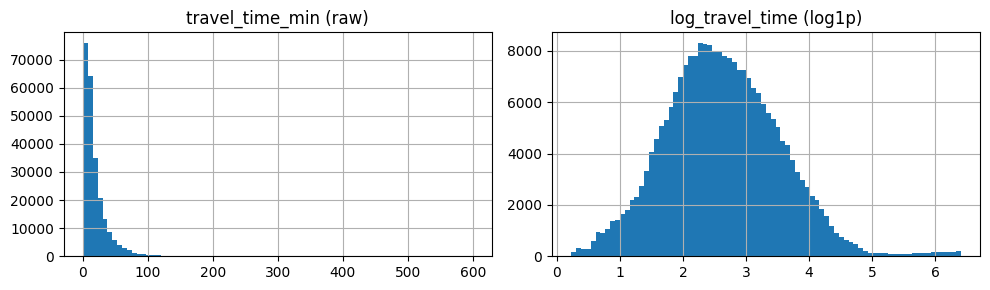

In [151]:
master['log_travel_time'] = np.log1p(master['travel_time_min'])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
master['travel_time_min'].hist(bins=80, ax=axes[0])
axes[0].set_title('travel_time_min (raw)')
master['log_travel_time'].hist(bins=80, ax=axes[1])
axes[1].set_title('log_travel_time (log1p)')
plt.tight_layout()
plt.show()

In [152]:
print("=== FINAL MASTER SCHEMA ===")
print(master.dtypes.to_string())
print("\n=== NULL CHECK ===")
nulls = master.isnull().sum()
if nulls.sum() == 0:
    print("✓ Zero nulls — ready to model")
else:
    print(nulls[nulls > 0])

print("\n=== TARGET DISTRIBUTION ===")
print(master[['travel_time_min','log_travel_time']].describe().round(2))

=== FINAL MASTER SCHEMA ===
distance_km                 float64
travel_time_min             float64
num_lanes                     Int64
num_signals                   Int64
hour                        Float64
day_of_week                   Int64
avg_speed_kmph              float64
temperature_c               float64
visibility_km               float64
timestamp_w          datetime64[ns]
is_rush_hour                  Int64
traffic_level_ord           float64
road_highway                  int64
road_residential              int64
road_urban                    int64
weather_clear                 int64
weather_fog                   int64
weather_rain                  int64
log_travel_time             float64

=== NULL CHECK ===
distance_km           1074
timestamp_w          23982
traffic_level_ord    32770
dtype: int64

=== TARGET DISTRIBUTION ===
       travel_time_min  log_travel_time
count        239919.00        239919.00
mean             21.80             2.63
std              40.64   

In [153]:
feature_cols = [c for c in master.columns
                if c not in ['travel_time_min','log_travel_time']]
print(f"Features ({len(feature_cols)}):", feature_cols)
print(f"\nTarget:  travel_time_min  (raw regression)")
print(f"Target:  log_travel_time  (log-transformed regression)")

Features (17): ['distance_km', 'num_lanes', 'num_signals', 'hour', 'day_of_week', 'avg_speed_kmph', 'temperature_c', 'visibility_km', 'timestamp_w', 'is_rush_hour', 'traffic_level_ord', 'road_highway', 'road_residential', 'road_urban', 'weather_clear', 'weather_fog', 'weather_rain']

Target:  travel_time_min  (raw regression)
Target:  log_travel_time  (log-transformed regression)


In [154]:
from pathlib import Path
out = Path('../data/processed/merged')
out.mkdir(exist_ok=True)

master.to_csv(out / 'master.csv', index=False)

size_mb = (out / 'master.csv').stat().st_size / 1e6
print(f"✓ master.csv saved  —  {len(master):,} rows × {master.shape[1]} cols  —  {size_mb:.1f} MB")

✓ master.csv saved  —  239,919 rows × 19 cols  —  23.8 MB
